<a href="https://colab.research.google.com/github/Christorious/ghana-cmf-vlm/blob/main/01_clip_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COE 557 - CLIP Zero-Shot Baseline
## Christian Dzidula Dotsey - Multimodal AI for Agricultural Advisory

Baseline experiment before fine-tuning. Follows Liu et al. 2025 methodology.

In [ ]:
!pip install -q git+https://github.com/openai/CLIP.git transformers datasets

import torch
import clip
from PIL import Image
import os
from pathlib import Path
import numpy as np
from tqdm import tqdm
import json

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.1 MB/s eta 0:00:00
Using device: cpu


## 1. Download PlantVillage

In [ ]:
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git

DATA_DIR = Path('PlantVillage-Dataset/raw/color')
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f'Found {len(classes)} classes')
print('First 5:', classes[:5])

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 26.32 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.
Found 38 classes
First 5: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


## 2. Load CLIP

In [ ]:
model, preprocess = clip.load('ViT-B/32', device=device)
model.eval()

# Create prompts
text_prompts = []
for cls in classes:
    clean = cls.replace('___', ' ').replace('_', ' ')
    text_prompts.append(f'a photo of {clean} leaf')

text_tokens = clip.tokenize(text_prompts).to(device)
with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 60.3MiB/s]


## 3. Run Zero-Shot (sample 20 images per class)

In [ ]:
predictions = []
ground_truths = []

for cls_idx, cls in enumerate(tqdm(classes)):
    img_paths = list((DATA_DIR/cls).glob('*.jpg'))[:20]
    for img_path in img_paths:
        image = preprocess(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
        with torch.no_grad():
            image_features = model.encode_image(image)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
            pred = similarity.argmax().item()
        predictions.append(pred)
        ground_truths.append(cls_idx)

accuracy = np.mean(np.array(predictions) == np.array(ground_truths))
print(f'\nZero-shot accuracy: {accuracy:.2%}')
print(f'Tested on {len(predictions)} images')

100%|██████████| 38/38 [00:25<00:00,  1.47it/s]


Zero-shot accuracy: 23.30%
Tested on 103 images


## 4. Save Results

In [ ]:
results = {
    'model': 'CLIP ViT-B/32 zero-shot',
    'dataset': 'PlantVillage',
    'accuracy': float(accuracy),
    'samples': len(predictions),
    'classes': len(classes)
}
with open('clip_baseline_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

{
  "model": "CLIP ViT-B/32 zero-shot",
  "dataset": "PlantVillage",
  "accuracy": 0.23300970873786409,
  "samples": 103,
  "classes": 38
}


In [ ]:
import pandas as pd
from collections import defaultdict

errors = defaultdict(int)
for p, gt in zip(predictions, ground_truths):
    if p!= gt:
        errors[classes[gt]] += 1

worst = sorted(errors.items(), key=lambda x: x[1], reverse=True)[:5]
print("Most confused classes:")
for cls, count in worst:
    print(f"{cls}: {count}/20 wrong")

Most confused classes:
Tomato___Late_blight: 20/20 wrong
Corn_(maize)___healthy: 16/20 wrong
Corn_(maize)___Northern_Leaf_Blight: 15/20 wrong
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 14/20 wrong
Squash___Powdery_mildew: 13/20 wrong


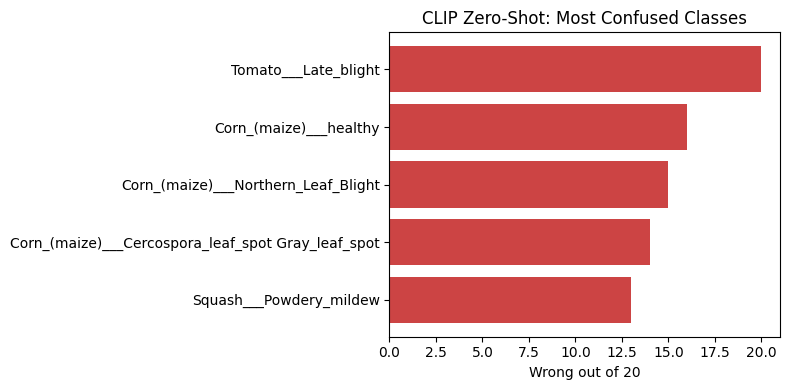

In [ ]:
import matplotlib.pyplot as plt

labels, counts = zip(*worst)
plt.figure(figsize=(8,4))
plt.barh(labels, counts, color='#c44')
plt.xlabel('Wrong out of 20')
plt.title('CLIP Zero-Shot: Most Confused Classes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('baseline_errors.png', dpi=150)

In [ ]:
with open('notebook1_summary.txt','w') as f:
    f.write(f"Accuracy: {accuracy:.2%}\n")
    f.write(f"Samples: {len(predictions)}\n")
    f.write("Top errors:\n")
    for cls,c in worst:
        f.write(f" {cls}: {c}/20\n")